# Quantify Risk: Generate Risk metrics
How does increasing renewable penetration affect grid variability?
In power systems, risk occurs when:
•	demand changes too fast 
•	generators cannot ramp fast enough 
•	reserves are insufficient 
•	frequency deviates 
So the core risk driver = extreme ramps, not average variability.
Therefore metrics should measure:
1.	Extreme ramps 
2.	Frequency of extreme ramps 
3.	Sustained ramps 
4.	Forecast difficulty 

RISK metrics included in this anlysis: 
1. Maximum Ramp: •	directly measures worst stress event 
2. Tail Probability (95%): •	measures how often extreme ramps occur based on today’s extreme grid stress level. Will apply different renewable senarios to quantify how often future system conditions exceed baseline extreme ramp levels.
3. Conditional Tail Expectation (CVaR-like): •	measures severity after extreme event happens 
4. 3-hour Ramp Magnitude: •	grid operators worry about sustained ramps 

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("C:/Renewable-PowerGrid-Risk")
PROCESSED_DIR = ROOT / 'data' / 'processed'

df=pd.read_csv(PROCESSED_DIR / 'hourly_load_renewable_merged.csv', parse_dates=['datetime'])
print(df.shape)

(26310, 22)


## Define RISK metrics
In this analysis, I choose these 4 to measure RISK: Maximum Ramp, Tail Probability (95%), Conditional Tail Expectation (CVaR-like), 3-hour Ramp Magnitude


In [7]:
def compute_risk_metrics(df):

    df = df.copy()
    df["ramp_1h"] = df["NET_LOAD"].diff()
    df["ramp_3h"] = df["NET_LOAD"].diff(3)
    # Compute the maximum absolute ramp over 1 hour
    max_ramp = df["ramp_1h"].abs().max()
    # Tail Probability (95%) 
    # The tail probability is estimated empirically as the fraction of time steps where the ramp magnitude exceeds the 95th percentile threshold.
    threshold = df["ramp_1h"].abs().quantile(0.95)
    tail_prob = (df["ramp_1h"].abs() > threshold).mean()
    #Conditional Tail Expectation (CVaR-like)
    conditional_tail = (
        df.loc[df["ramp_1h"].abs() > threshold, "ramp_1h"]
        .abs()
        .mean()
    )
    # Compute the maximum absolute ramp over 3 hours
    max_ramp_3h = df["ramp_3h"].abs().max()

    return {
        "max_ramp_1h": max_ramp,
        "threshold_P95": threshold,
        "tail_probability": tail_prob,
        "conditional_tail": conditional_tail,
        "max_ramp_3h": max_ramp_3h,
    }

In [8]:
print(compute_risk_metrics(df))

{'max_ramp_1h': 15862.660755310055, 'threshold_P95': 5372.963952272039, 'tail_probability': 0.050019004180919806, 'conditional_tail': 7133.286129469197, 'max_ramp_3h': 28972.656092180354}


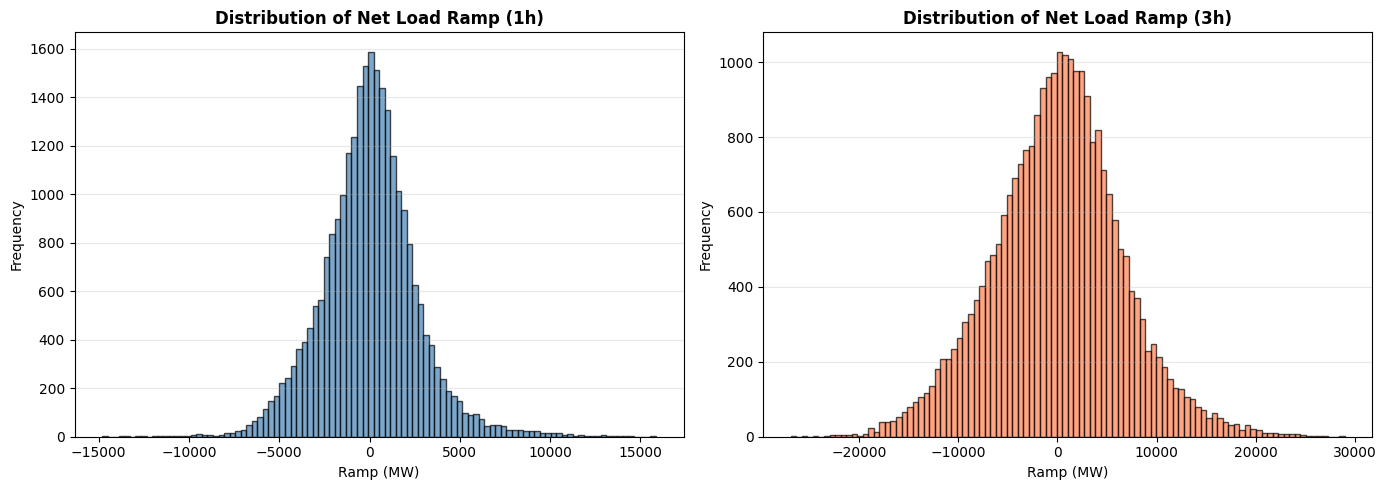

In [12]:
df["ramp_1h"] = df["NET_LOAD"].diff()
df["ramp_3h"] = df["NET_LOAD"].diff(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: 1-hour ramp
axes[0].hist(df["ramp_1h"].dropna(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Net Load Ramp (1h)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Ramp (MW)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.3)

# Right subplot: 3-hour ramp
axes[1].hist(df["ramp_3h"].dropna(), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of Net Load Ramp (3h)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Ramp (MW)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Left: 1-hour ramp distribution (blue) — shows tighter, more concentrated distribution
## Right: 3-hour ramp distribution (coral) — shows wider spread with larger extreme values
The side-by-side layout makes it easy to compare how ramp magnitudes change over different timescales. The 3-hour ramp naturally has larger swings since it aggregates changes over a longer period.

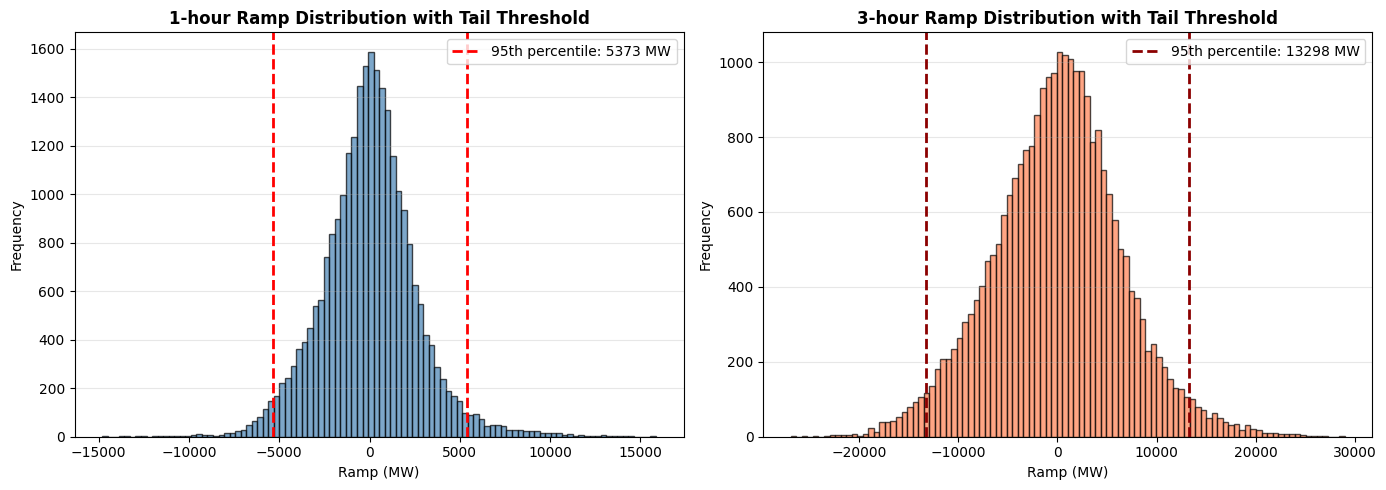

In [14]:
#Tail Region Highlight
#Purpose: visually show extreme events for both 1h and 3h ramps
threshold_1h = df["ramp_1h"].abs().quantile(0.95)
threshold_3h = df["ramp_3h"].abs().quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: 1-hour ramp with tail threshold
axes[0].hist(df["ramp_1h"].dropna(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(threshold_1h, color='red', linestyle="--", linewidth=2, label=f'95th percentile: {threshold_1h:.0f} MW')
axes[0].axvline(-threshold_1h, color='red', linestyle="--", linewidth=2)
axes[0].set_title("1-hour Ramp Distribution with Tail Threshold", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Ramp (MW)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right subplot: 3-hour ramp with tail threshold
axes[1].hist(df["ramp_3h"].dropna(), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(threshold_3h, color='darkred', linestyle="--", linewidth=2, label=f'95th percentile: {threshold_3h:.0f} MW')
axes[1].axvline(-threshold_3h, color='darkred', linestyle="--", linewidth=2)
axes[1].set_title("3-hour Ramp Distribution with Tail Threshold", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Ramp (MW)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
# This visually defines risk region for both timescales.

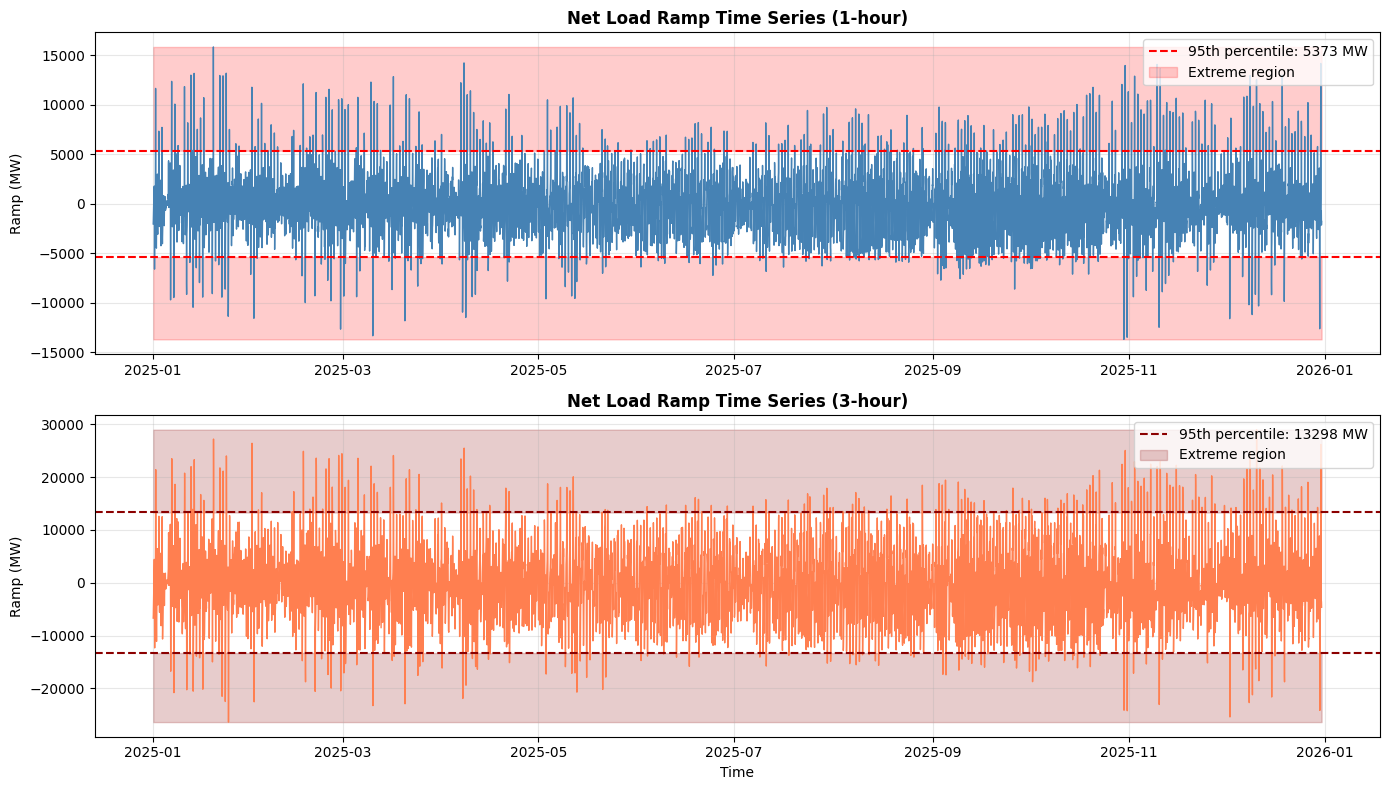

In [18]:
#Ramp Time Series (Extreme Events)
#Purpose: show when risk occurs
# Threshold defines the 95th percentile of ramp magnitudes, marking extreme events
tmp=df[df['datetime'].between('2025-01-01', '2025-12-31')]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top subplot: 1-hour ramp time series
axes[0].plot(tmp["datetime"], tmp["ramp_1h"], linewidth=1, color='steelblue')
axes[0].axhline(threshold_1h, color='red', linestyle="--", linewidth=1.5, label=f'95th percentile: {threshold_1h:.0f} MW')
axes[0].axhline(-threshold_1h, color='red', linestyle="--", linewidth=1.5)
axes[0].fill_between(tmp["datetime"], threshold_1h, tmp["ramp_1h"].max(), alpha=0.2, color='red', label='Extreme region')
axes[0].fill_between(tmp["datetime"], -threshold_1h, tmp["ramp_1h"].min(), alpha=0.2, color='red')
axes[0].set_title("Net Load Ramp Time Series (1-hour)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Ramp (MW)")
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Bottom subplot: 3-hour ramp time series
axes[1].plot(tmp["datetime"], tmp["ramp_3h"], linewidth=1, color='coral')
axes[1].axhline(threshold_3h, color='darkred', linestyle="--", linewidth=1.5, label=f'95th percentile: {threshold_3h:.0f} MW')
axes[1].axhline(-threshold_3h, color='darkred', linestyle="--", linewidth=1.5)
axes[1].fill_between(tmp["datetime"], threshold_3h, tmp["ramp_3h"].max(), alpha=0.2, color='darkred', label='Extreme region')
axes[1].fill_between(tmp["datetime"], -threshold_3h, tmp["ramp_3h"].min(), alpha=0.2, color='darkred')
axes[1].set_title("Net Load Ramp Time Series (3-hour)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Ramp (MW)")
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
#This shows clustering and temporal patterns of extreme ramps.

Top: 1-hour ramp with 95th percentile threshold at 5,373 MW (red dashed lines)

Bottom: 3-hour ramp with 95th percentile threshold at 13,298 MW (red dashed lines)

The shaded red regions highlight the extreme event zones above and below each threshold. This visualization makes it easy to see the temporal clustering and frequency of extreme ramps at different timescales throughout 2025.

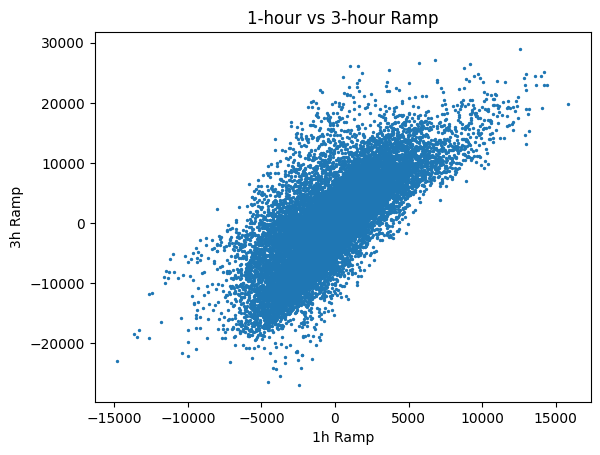

In [ ]:
#1h vs 3h Ramp Comparison
#Purpose: show sustained risk
plt.figure()
plt.scatter(df["ramp_1h"], df["ramp_3h"], s=2)
plt.title("1-hour vs 3-hour Ramp")
plt.xlabel("1h Ramp")
plt.ylabel("3h Ramp")
plt.show()
#This shows:
#sustained variability 
#operational challenge 


In [21]:
#Monthly Extreme Event Analysis
#Purpose: show seasonal patterns in risk
#However, since we only included 3 years of data, we may not have enough evidence to draw strong conclusions.
df["month"] = pd.to_datetime(df["datetime"]).dt.month

threshold = df["ramp_1h"].abs().quantile(0.95)

df["extreme"] = df["ramp_1h"].abs() > threshold

monthly_extremes = df.groupby("month")["extreme"].sum()
print(monthly_extremes)
monthly_prob = df.groupby("month")["extreme"].mean()
print(monthly_prob)

month
1     117
2      94
3      86
4      70
5      56
6      58
7     102
8     149
9     171
10    125
11    131
12    157
Name: extreme, dtype: int64
month
1     0.052419
2     0.046078
3     0.038582
4     0.032407
5     0.025090
6     0.026852
7     0.045699
8     0.066756
9     0.079167
10    0.056004
11    0.060396
12    0.070341
Name: extreme, dtype: float64
